In [1]:
#imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
#load data
df = pd.read_csv("AB_NYC_2019.csv")
df.head()
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum())
print(df.describe(include="all"))

(48895, 16)
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type

In [3]:
# cleandata
df = df.copy()

# Drop columns that are identifiers or text-heavy fields we are not using 
drop_cols = ["id", "name", "host_id", "host_name", "last_review"]
df = df.drop(columns=drop_cols, errors="ignore")

df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(df.isnull().sum())




neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


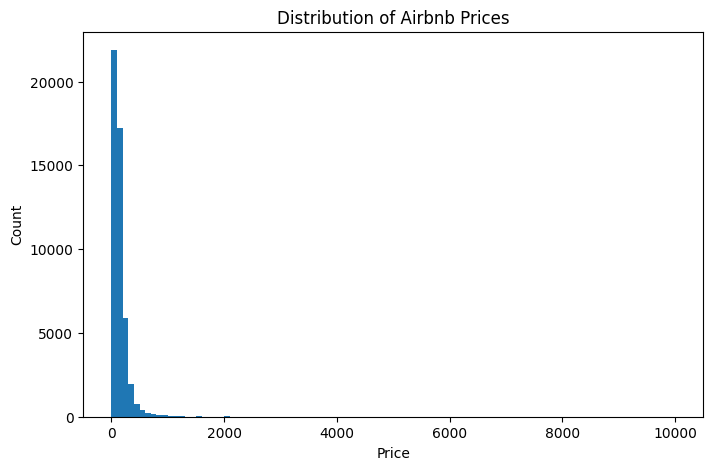

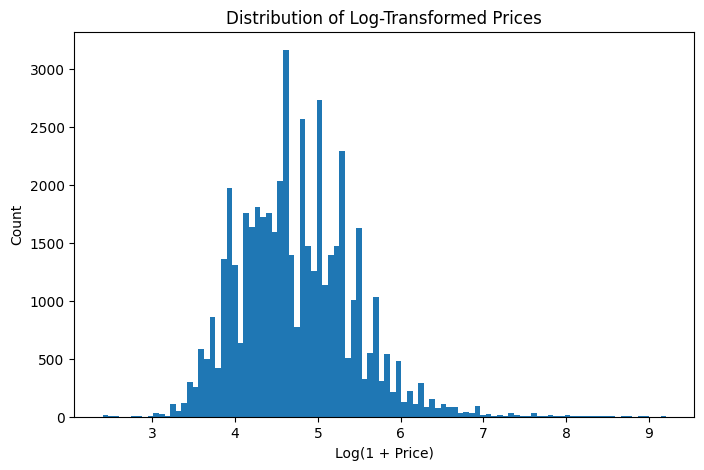

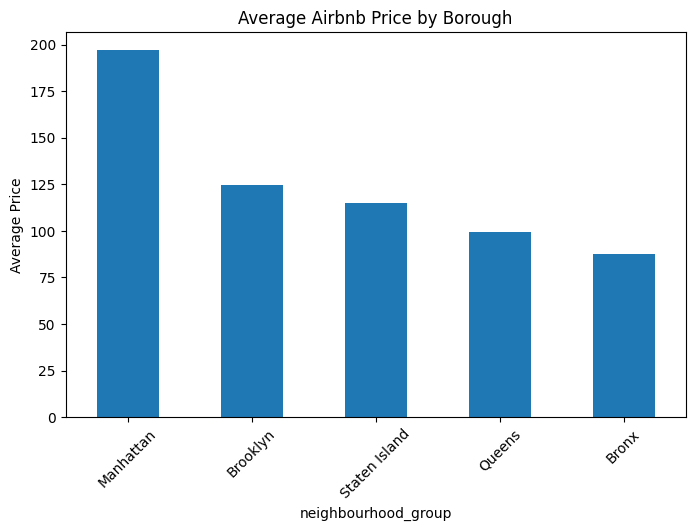

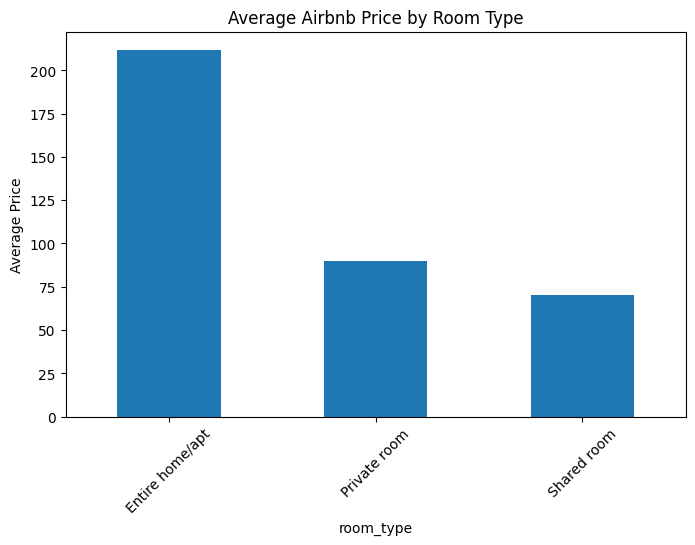

In [4]:
# price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Airbnb Prices")
plt.show()

# log price distribution
df = df[df["price"] > 0].copy()
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=100)
plt.xlabel("Log(1 + Price)")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed Prices")
plt.show()


# average price by bourough
borough_means = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
borough_means.plot(kind="bar")
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by Borough")
plt.xticks(rotation=45)
plt.show()

# average price by room type
room_means = df.groupby("room_type")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
room_means.plot(kind="bar")
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by Room Type")
plt.xticks(rotation=45)
plt.show()

In [5]:
# features 
target = "log_price"

features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = df[features]
y = df[target]

In [6]:
# training 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(39107, 10) (9777, 10)


In [7]:
#pipeline
categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
#model
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

In [9]:
#train and evaluate models
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)

               Model       MAE      RMSE        R2
3      Random Forest  0.312087  0.442716  0.591870
2      Decision Tree  0.331304  0.469842  0.540326
1   Ridge Regression  0.343004  0.477494  0.525229
0  Linear Regression  0.343063  0.477726  0.524768


In [10]:
#cross validation
cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    )
    
    cv_results.append({
        "Model": name,
        "CV Mean R2": scores.mean(),
        "CV Std R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV Mean R2", ascending=False)
print(cv_results_df)

               Model  CV Mean R2  CV Std R2
3      Random Forest    0.557668   0.037332
1   Ridge Regression    0.525206   0.037569
0  Linear Regression    0.524588   0.037349
2      Decision Tree    0.485238   0.056785


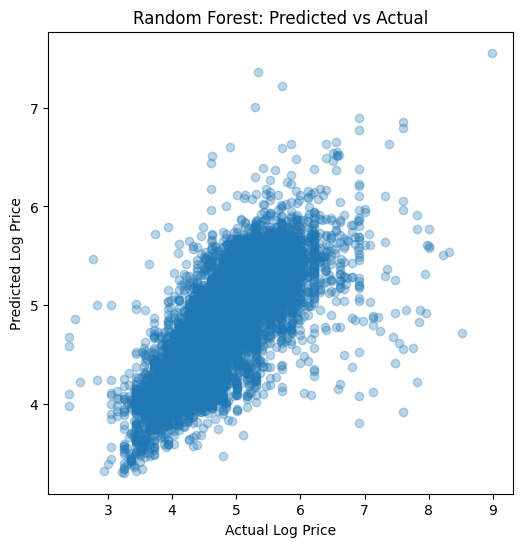

Sample actual prices:
41320     99.0
22079     90.0
18778     80.0
25494     60.0
44319     90.0
31422    100.0
5954     200.0
33502     45.0
17258     60.0
6179      29.0
Name: log_price, dtype: float64

Sample predicted prices:
[ 97.4403149   87.6708326  105.86255547  62.26627676  89.09496668
  78.11211245 116.6581741   60.95194594  63.14979809  40.4025414 ]


In [11]:
#prediction vs actual
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

actual_price = np.expm1(y_test)
pred_price = np.expm1(y_pred_rf)

print("Sample actual prices:")
print(actual_price[:10])

print("\nSample predicted prices:")
print(pred_price[:10])